<a href="https://colab.research.google.com/github/bentadev/tp-final-ds-grupo3/blob/main/TP_Airbnb_Grupo3_Madrid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🏙️📊TP FINAL: ANÁLISIS PREDICTIVO DE PRECIOS AIRBNB**

---

## **🎓Información Institucional**
**🏫Institución:** UOCRA – IFTS N° 33  
**🎓Carrera:** `Ciencia de datos e inteligencia artificial`  
**📚Materia:** `Ciencia de datos`  
**👩‍🏫Docente a cargo:** `Marisa Cánovas`  
**👥Modalidad:** Grupal 4 grupos × 5 a 6 integrantes  
**📅Fecha de entrega:** `20-6-26`  

---

## **👨‍💻 Integrantes del Grupo**

**📊Fase de Análisis (EDA)**
- `Priscila Chino`
- `Rosmery Ramirez`

**🧹Fase de Transformación**
- `Martin Bentancor`

**🤖Fase de Modelo de IA**
- `Maria Mamani`
- `Emmanuel Flores`:

---

## **🎯Objetivo del Trabajo**
Desarrollar un flujo completo de **Ciencia de Datos** aplicado al sector inmobiliario temporario. Cada grupo deberá **limpiar**, **explorar** y **modelar un dataset** real de **Airbnb** para **predecir** el precio por noche y comunicar hallazgos accionables para un inversor. Realizando:

- 🧹 Limpieza y preparación de datos
- 📊 Análisis exploratorio (EDA)
- 🤖 Modelado predictivo de precios por noche
- 📈 Evaluación de desempeño del modelo
- 🧠 Interpretación de variables relevantes

---

## **🌍Asignaciónd de Ciudades y Datasets**
Cada grupo trabaja con una **ciudad** distinta. La estructura de **columnas** es estandarizada, pero la dinámica de mercado, **outliers** y distribución de precios variarán.

| Grupo | Ciudad | País | Enlace de descarga directa |
|:---:|:---|:---|:---|
| **2** | **New York City** | 🇺 USA |https://insideairbnb.com/get-the-data/
| **3** | **Madrid** | 🇪🇸 España |https://insideairbnb.com/get-the-data/
| **4** | **Buenos Aires** | 🇦🇷 Argentina |https://insideairbnb.com/get-the-data/
  **5** | **Tokio** | Japón|https://insideairbnb.com/get-the-data/
https://insideairbnb.com/get-the-data/ y localizar la ciudad solicitada

---

## **📌Entregables**
1. **Notebook Jupyter (`.ipynb`)**: Código ejecutable, comentarios técnicos y celdas de Markdown explicativas.
2. **Presentación Oral (10-15 min)**: Síntesis del proceso, visualizaciones clave, métricas del modelo y conclusión de negocio.
3. **Defensa Técnica**: Cada integrante deberá responder preguntas sobre su sección del código.

---

## **✅Checklist de Trabajo (Requisitos mínimos)**
Marcar cada ítem completado dentro del notebook:

- [ ] Carga del dataset y exploración inicial
- [ ] Limpieza de la variable objetivo `price`: conversión a numérico y manejo de valores extremos.
- [ ] Tratamiento de datos faltantes y duplicados (documentar la decisión tomada).
- [ ] **Codificación de variables categóricas**: Transformar columnas de texto (ej: `room_type`, `neighbourhood`) a formato numérico compatible con el modelo.
- [ ] Selección de features y división Train/Test.
- [ ] Entrenamiento de un modelo de regresión y evaluación con métricas estándar (R², MAE/RMSE).
- [ ] Interpretación de coeficientes: ¿qué variables explican mejor el precio en esta ciudad?
- [ ] Visualizaciones claras y etiquetadas que respalden las conclusiones.

---

## **🏆Rúbrica de Evaluación (100 puntos)**

| Criterio | Descripción | Puntaje |
|----------|-------------|:-------:|
| **Proceso de Limpieza** | Manejo consistente de nulos, tipos de datos y outliers. Documentación clara de decisiones. | 25 |
| **Análisis Exploratorio** | Visualizaciones pertinentes, bien construidas y con interpretación contextual. | 25 |
| **Modelado y Métricas** | Pipeline correcto, evaluación en test, interpretación técnica de resultados. | 25 |
| **Defensa y Comunicación** | Claridad expositiva, dominio técnico individual, capacidad de justificar decisiones. | 25 |
| **TOTAL** | | **100** |

---

## **🛡️Política de Integridad Académica**
- Se permite consultar la documentación oficial de **Pandas**, **Scikit-Learn** y foros técnicos para resolver errores de sintaxis.
- **No se aceptará** código generado íntegramente por IA o copiado de compañeros de otro grupo. Durante la defensa oral se solicitará la explicación línea por línea de secciones claves.
- El objetivo es evaluar el **criterio técnico y la capacidad de resolución**, no la velocidad de obtención de un script funcional.
- Cualquier indicio de autoría no verificable derivará en la instancia de recuperación o reprobación según el reglamento institucional.

---

## **💡Consejo Pedagógico**
> *"En **Ciencia de Datos** aplicada, un **R²** alto no garantiza un buen análisis. Lo que diferencia un trabajo académico de un script automático es la capacidad de explicar **por qué** se tomó cada decisión de limpieza, **qué** limitaciones tiene el modelo y **cómo** se traduce eso al contexto real de la ciudad analizada."*

---

## **📬Entrega**
- **Plataforma:** `Moodle `
- **Nombre de archivo:** `TP_Airbnb_GrupoX_Ciudad.ipynb`
- **Fecha límite:** `20-6-26`




In [ ]:
# Librerías para el análisis y transformación de datos.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para el modelo de IA.

In [ ]:
# Ruta Raw del dataset a traves del GitHub.
ruta_dataset = 'https://raw.githubusercontent.com/bentadev/tp-final-ds-grupo3/refs/heads/main/dataset_airbnb_madrid.csv'

# Carga del dataset.
dataset = pd.read_csv(ruta_dataset)

# Copia segura de trabajo.
df = dataset.copy()

In [ ]:
# Diccionario con las traducciones exactas de las 17 columnas.
diccionario_traduccion = {
    "id": "id_alojamiento",
    "name": "nombre_alojamiento",
    "host_id": "id_anfitrion",
    "host_name": "nombre_anfitrion",
    "neighbourhood_group": "grupo_barrio",
    "neighbourhood": "barrio",
    "latitude": "latitud",
    "longitude": "longitud",
    "room_type": "tipo_habitacion",
    "price": "precio",
    "minimum_nights": "minimo_noches",
    "number_of_reviews": "cantidad_resenas",
    "last_review": "ultima_resena",
    "reviews_per_month": "resenas_por_mes",
    "calculated_host_listings_count": "cantidad_alojamientos_anfitrion",
    "availability_365": "disponibilidad_anual",
    "number_of_reviews_ltm": "resenas_ultimos_12_meses",
    "license": "licencia"
}

# Aplicmaos el cambio de forma permanente.
df.rename(columns=diccionario_traduccion, inplace=True)

# Vista de control para verificar los nuevos nombres en español.
print(df.columns.tolist())

['id_alojamiento', 'nombre_alojamiento', 'id_anfitrion', 'nombre_anfitrion', 'grupo_barrio', 'barrio', 'latitud', 'longitud', 'tipo_habitacion', 'precio', 'minimo_noches', 'cantidad_resenas', 'ultima_resena', 'resenas_por_mes', 'cantidad_alojamientos_anfitrion', 'disponibilidad_anual', 'resenas_ultimos_12_meses', 'licencia']


# **📊1. Análisis Exploratorio de Datos (EDA)**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id_alojamiento                   25000 non-null  int64  
 1   nombre_alojamiento               25000 non-null  object 
 2   id_anfitrion                     25000 non-null  int64  
 3   nombre_anfitrion                 24903 non-null  object 
 4   grupo_barrio                     25000 non-null  object 
 5   barrio                           25000 non-null  object 
 6   latitud                          25000 non-null  float64
 7   longitud                         25000 non-null  float64
 8   tipo_habitacion                  25000 non-null  object 
 9   precio                           18953 non-null  float64
 10  minimo_noches                    25000 non-null  int64  
 11  cantidad_resenas                 25000 non-null  int64  
 12  ultima_resena     

## Fase 1: Calidad de Datos y Diagnóstico de Faltantes


### 1.1. Análisis del Target (price):

* Calcular estadísticas clave: media, mediana, mínimo, máximo y desvío estándar.
* Gráfico recomendado: Histograma y Boxplot del precio para ver la forma de la distribución (seguramente tendrá una asimetría hacia la derecha por los precios altos).


Estadísticas descriptivas para 'precio':
count    18953.000000
mean       156.691447
std        492.255350
min          8.000000
25%         70.000000
50%        110.000000
75%        164.000000
max      25654.000000
Name: precio, dtype: float64


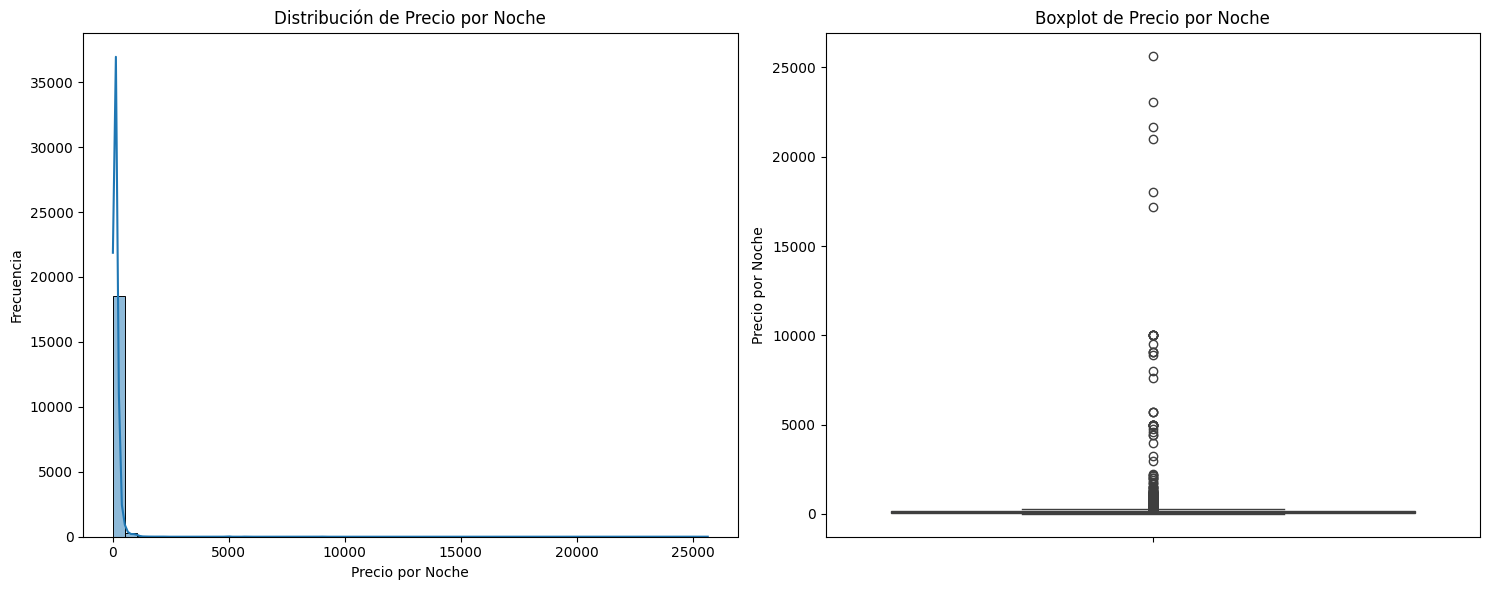

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular estadísticas clave para la columna 'Precio_Noche'
print("\nEstadísticas descriptivas para 'precio':")
print(df['precio'].describe())

# 2. Visualizar la distribución de 'Precio_Noche'
plt.figure(figsize=(15, 6))

# Histograma
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
sns.histplot(df['precio'].dropna(), bins=50, kde=True)
plt.title('Distribución de Precio por Noche')
plt.xlabel('Precio por Noche')
plt.ylabel('Frecuencia')

# Boxplot
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
sns.boxplot(y=df['precio'].dropna())
plt.title('Boxplot de Precio por Noche')
plt.ylabel('Precio por Noche')

plt.tight_layout()
plt.show()

### Duplicados en la columna 'precio'

In [ ]:
# Identificar y mostrar las filas donde el 'Precio_Noche' está duplicado
duplicados_precio = df[df['precio'].duplicated(keep=False)].sort_values(by='precio')

print(f"\n--- Filas con 'precio' duplicado ({len(duplicados_precio)} filas) ---")
display(duplicados_precio.head(10)) # Mostrar las primeras 10 filas para una vista previa
print("-" * 70)


--- Filas con 'precio' duplicado (24802 filas) ---


,id_alojamiento,nombre_alojamiento,id_anfitrion,nombre_anfitrion,grupo_barrio,barrio,latitud,longitud,tipo_habitacion,precio,minimo_noches,cantidad_resenas,ultima_resena,resenas_por_mes,cantidad_alojamientos_anfitrion,disponibilidad_anual,resenas_ultimos_12_meses,licencia
23452,1437001338074317170,Visita y descansa en Madrid,407104327,Raquel,Ciudad Lineal,Pueblo Nuevo,40.431827,-3.643968,Private room,8.0,2,1,2025-06-28,0.38,2,27,1,NaN
15012,1052771142273730407,Excelente habitación,209525802,Juan David,Arganzuela,Chopera,40.394836,-3.699599,Private room,8.0,1,0,NaN,NaN,1,85,0,NaN
15759,1100744628408531352,"Piso en Salamanca, centro",28810090,Karla,Salamanca,Guindalera,40.436240,-3.672420,Private room,9.0,5,1,2024-12-02,0.10,1,0,1,NaN
14847,1044295365361757805,Bello dpto en manzanares,475355535,Manuel,Carabanchel,Comillas,40.395473,-3.708662,Private room,9.0,1,1,2024-01-01,0.05,2,128,0,NaN
22147,1391346173939572139,Un espacio agradable y cómodo.,687944221,Wendis Dayanis,Hortaleza,Apostol Santiago,40.481185,-3.658422,Private room,9.0,1,0,NaN,NaN,1,9,0,NaN
23647,1443448776185683992,Apart. Duplex Puerta de Toledo,446760611,Raul,Centro,Embajadores,40.405770,-3.706440,Entire home/apt,9.0,7,0,NaN,NaN,36,350,0,NaN
14838,1043392917218974369,Bello alojamiento en manzanares,475355535,Manuel,Carabanchel,Comillas,40.394920,-3.708670,Private room,9.0,1,0,NaN,NaN,2,99,0,NaN
12355,892491869203638852,Bed in Cute & Shared Room near Center,514431098,Javier,Carabanchel,Vista Alegre,40.378989,-3.749394,Shared room,15.0,3,41,2025-09-04,1.47,5,66,11,NaN
15748,1099992890034269428,Hermosa habitación cerca al aeropuerto,564097287,Carlos,Puente de Vallecas,San Diego,40.385762,-3.669942,Private room,15.0,1,1,2024-06-10,0.06,1,184,0,NaN
7768,49898995,Habitación bonita Embajadores metro Tirso Molina,402370216,W Rodrigo,Centro,Embajadores,40.406520,-3.702330,Private room,15.0,10,22,2024-10-31,0.43,6,176,2,NaN


----------------------------------------------------------------------


In [ ]:
# Para ver la cantidad de valores únicos de precio que están duplicados
print("\n--- Conteo de 'precio' duplicados ---")
conteo_precios_duplicados = duplicados_precio['precio'].value_counts()
display(conteo_precios_duplicados.head(10)) # Mostrar los 10 precios más duplicados
print("-" * 70)


--- Conteo de 'precio' duplicados ---


,count
precio,
90.0,216
80.0,174
85.0,164
100.0,164
60.0,161
110.0,158
105.0,157
40.0,154
65.0,150


----------------------------------------------------------------------


### Identificación de Outliers en 'Precio_Noche' (Método IQR)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener la columna 'precio' sin valores nulos
precio_clean = df['precio'].dropna()

# Calcular los cuartiles (Q1 y Q3) y el rango intercuartílico (IQR)
Q1 = precio_clean.quantile(0.25)
Q3 = precio_clean.quantile(0.75)
IQR = Q3 - Q1

# Definir los límites para identificar outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"\n--- Análisis de Outliers para 'precio' ---")
print(f"Primer Cuartil (Q1): {Q1:.2f}")
print(f"Tercer Cuartil (Q3): {Q3:.2f}")
print(f"Rango Intercuartílico (IQR): {IQR:.2f}")
print(f"Límite Inferior para Outliers: {limite_inferior:.2f}")
print(f"Límite Superior para Outliers: {limite_superior:.2f}")

# Identificar outliers
outliers_inferiores = precio_clean[precio_clean < limite_inferior]
outliers_superiores = precio_clean[precio_clean > limite_superior]

print(f"\nCantidad de outliers inferiores: {len(outliers_inferiores)}")
print(f"Cantidad de outliers superiores: {len(outliers_superiores)}")

print("\n--- Ejemplos de Outliers Superiores (primeros 10) ---")
display(outliers_superiores.sort_values(ascending=False).head(10))
print("-" * 60)



--- Análisis de Outliers para 'precio' ---
Primer Cuartil (Q1): 70.00
Tercer Cuartil (Q3): 164.00
Rango Intercuartílico (IQR): 94.00
Límite Inferior para Outliers: -71.00
Límite Superior para Outliers: 305.00

Cantidad de outliers inferiores: 0
Cantidad de outliers superiores: 1183

--- Ejemplos de Outliers Superiores (primeros 10) ---


,precio
579,25654.0
8397,23085.0
4976,21685.0
7174,21000.0
13321,18000.0
2260,17159.0
19008,10000.0
12787,9999.0
12791,9999.0
12797,9999.0


------------------------------------------------------------


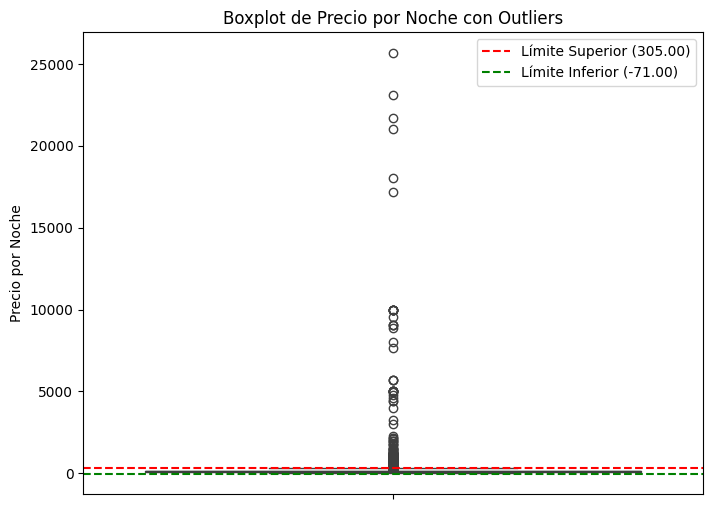

In [ ]:
# Visualización de Outliers con Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['precio'].dropna())
plt.title('Boxplot de Precio por Noche con Outliers')
plt.ylabel('Precio por Noche')

# Opcional: Añadir líneas para los límites de outlier en el boxplot
# Nota: Estas líneas pueden no ser visibles si no hay outliers más allá de los bigotes
plt.axhline(y=limite_superior, color='r', linestyle='--', label=f'Límite Superior ({limite_superior:.2f})')
plt.axhline(y=limite_inferior, color='g', linestyle='--', label=f'Límite Inferior ({limite_inferior:.2f})')
plt.legend()
plt.show()

## Análisis de Percentiles y Distribución Acumulada para 'Precio_Noche'

In [ ]:
# Filtrar valores nulos de Precio_Noche para el análisis
precio_noche_filtrado = df['precio'].dropna()

# Calcular percentiles clave
percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999, 1.0]
valores_percentiles = precio_noche_filtrado.quantile(percentiles)

print("--- Percentiles de precio ---")
for p, val in zip(percentiles, valores_percentiles):
    print(f"P{p*100:.1f}: {val:.2f}")
print("-" * 30)

--- Percentiles de precio ---
P1.0: 21.00
P5.0: 31.00
P10.0: 41.00
P25.0: 70.00
P50.0: 110.00
P75.0: 164.00
P90.0: 249.00
P95.0: 343.00
P99.0: 793.36
P99.5: 1000.00
P99.9: 7641.10
P100.0: 25654.00
------------------------------


#### Interpretación de los Percentiles

*   **Percentiles:** Nos permiten entender la dispersión de los datos. Por ejemplo, el P50 (mediana) nos dice que el 50% de las propiedades tienen un precio igual o inferior a ese valor. Los percentiles más altos (P90, P95, P99) confirman la presencia de precios muy elevados, lo que ya habíamos identificado como outliers.

In [ ]:
# Filtrar el DataFrame para mostrar filas donde 'Precio_Noche' es mayor a 150
filas_precio_alto = df[df['precio'] > 5000]
# Mostrar las primeras 20 filas completas de este subconjunto
display(filas_precio_alto.head(8))

,id_alojamiento,nombre_alojamiento,id_anfitrion,nombre_anfitrion,grupo_barrio,barrio,latitud,longitud,tipo_habitacion,precio,minimo_noches,cantidad_resenas,ultima_resena,resenas_por_mes,cantidad_alojamientos_anfitrion,disponibilidad_anual,resenas_ultimos_12_meses,licencia
306,2294171,Buhardilla en el Madrid de los Austrias,11719928,Mariano,Centro,Sol,40.417377,-3.706745,Entire home/apt,9515.0,4,8,2024-12-29,0.31,3,0,1,NaN
579,5361601,♡Comfort 2 Bedrooms/2 Bathrooms apt. WiFi & AC,3983613,Raul,Centro,Sol,40.418460,-3.707240,Entire home/apt,25654.0,3,149,2025-09-09,1.19,2,28,13,ESFCNT0000280910006330040000000000000000000000...
2260,18816591,PUERTA DEL ANGEL,1408525,Mad4Rent,Latina,Puerta del Angel,40.409160,-3.732560,Entire home/apt,17159.0,3,63,2025-02-20,0.62,75,0,7,00
4976,34570478,Apartamento,260848309,Elo,Centro,Sol,40.417356,-3.701313,Entire home/apt,21685.0,2,117,2023-06-25,1.53,1,137,0,NaN
6985,43828290,Madrid,17011402,Nicolas,Centro,Palacio,40.421700,-3.710090,Entire home/apt,5706.0,4,4,2021-12-07,0.07,10,243,0,NaN
7063,44265422,Madrid,17011402,Nicolas,Centro,Universidad,40.425070,-3.711350,Entire home/apt,5706.0,5,6,2021-10-21,0.11,10,243,0,NaN
7072,44305807,Alquilo Apartamento Centro,290977158,Maria,Arganzuela,Imperial,40.406730,-3.717570,Entire home/apt,7623.0,40,0,NaN,NaN,1,270,0,NaN
7174,45249073,Captivating Apartment in Madrid near El Retiro...,362191258,Juanita - BELVILLA,Puente de Vallecas,Palomeras Bajas,40.391400,-3.664250,Entire home/apt,21000.0,1,0,NaN,NaN,1,365,0,VT-11002


## 1.2 Analizar Columnas Total_reseñas y Disponibilidad_Anual y Fechas de ultimas reseñas
Determinar si son columnas con valores nulos, faltantes, si tienes datos malos. Todo analisis principal para saber si son columnas que nos pueden servir o mejor liminarlas de una, porque son malas reseñas sesgadas.

In [ ]:
# 1. Calculamos las métricas de salud por cada columna
total_filas = df.shape[0]

# Conteo de nulos y sus porcentajes
nulos_por_columna = df.isnull().sum()
porcentaje_nulos = (nulos_por_columna / total_filas) * 100

# Conteo de valores únicos (Cardinalidad)
valores_unicos = df.nunique()

# 2. Consolidamos el Reporte Clínico del Dataset
reporte_salud = pd.DataFrame({
    'Tipo_de_Dato': df.dtypes,
    'Valores_Nulos': nulos_por_columna,
    'Porcentaje_Nulos': porcentaje_nulos,
    'Valores_Unicos_Tasa': valores_unicos
})

# Formateamos el porcentaje para una lectura ejecutiva
reporte_salud['Porcentaje_Nulos'] = reporte_salud['Porcentaje_Nulos'].map('{:.2f}%'.format)

print("--- REPORTE DE SALUD CLÍNICA DE LAS COLUMNAS ---")
display(reporte_salud)
print("-" * 70)

# =====================================================================
# 3. DETECCIÓN AUTOMÁTICA DE COLUMNAS CANDIDATAS A ELIMINACIÓN DE UNA
# =====================================================================
print("🚨 EVALUACIÓN TÉCNICA DE DESCARTE DIRECTO:")

columnas_a_borrar = []

for columna in df.columns:
    pct_vacios = (df[columna].isnull().sum() / total_filas) * 100
    unicos = df[columna].nunique()

    # Regla 1: Demasiados nulos (más del 50% de la columna vacía)
    if pct_vacios > 50.0:
        print(f"❌ '{columna}': Candidata a borrar de una. Tiene {pct_vacios:.2f}% de nulos (Insalvable).")
        columnas_a_borrar.append(columna)

    # Regla 2: Alta cardinalidad en texto (ID o nombres que no aportan matemática)
    elif df[columna].dtype == 'object' and unicos > (total_filas * 0.5):
        print(f"❌ '{columna}': Candidata a borrar de una. Es texto libre con demasiada variedad ({unicos} únicos). Ruido puro para la IA.")
        columnas_a_borrar.append(columna)

    # Regla 3: Varianza Cero (Casi todas las filas tienen exactamente el mismo dato)
    elif unicos == 1:
        print(f"❌ '{columna}': Candidata a borrar de una. Varianza Cero (Todas las filas contienen el mismo valor). No enseña nada.")
        columnas_a_borrar.append(columna)

    else:
        print(f"✅ '{columna}': Variable Viable. Pasa a la fase de limpieza estándar/imputación.")

print(f"\n💡 RECOMENDACIÓN FINAL: Podés eliminar directamente estas columnas de tu base de entrenamiento: {columnas_a_borrar}")

--- REPORTE DE SALUD CLÍNICA DE LAS COLUMNAS ---


,Tipo_de_Dato,Valores_Nulos,Porcentaje_Nulos,Valores_Unicos_Tasa
id_alojamiento,int64,0,0.00%,25000
nombre_alojamiento,object,0,0.00%,23295
id_anfitrion,int64,0,0.00%,10453
nombre_anfitrion,object,97,0.39%,3903
grupo_barrio,object,0,0.00%,21
barrio,object,0,0.00%,128
latitud,float64,0,0.00%,15630
longitud,float64,0,0.00%,15247
tipo_habitacion,object,0,0.00%,4
precio,float64,6047,24.19%,719


----------------------------------------------------------------------
🚨 EVALUACIÓN TÉCNICA DE DESCARTE DIRECTO:
✅ 'id_alojamiento': Variable Viable. Pasa a la fase de limpieza estándar/imputación.
❌ 'nombre_alojamiento': Candidata a borrar de una. Es texto libre con demasiada variedad (23295 únicos). Ruido puro para la IA.
✅ 'id_anfitrion': Variable Viable. Pasa a la fase de limpieza estándar/imputación.
✅ 'nombre_anfitrion': Variable Viable. Pasa a la fase de limpieza estándar/imputación.
✅ 'grupo_barrio': Variable Viable. Pasa a la fase de limpieza estándar/imputación.
✅ 'barrio': Variable Viable. Pasa a la fase de limpieza estándar/imputación.
✅ 'latitud': Variable Viable. Pasa a la fase de limpieza estándar/imputación.
✅ 'longitud': Variable Viable. Pasa a la fase de limpieza estándar/imputación.
✅ 'tipo_habitacion': Variable Viable. Pasa a la fase de limpieza estándar/imputación.
✅ 'precio': Variable Viable. Pasa a la fase de limpieza estándar/imputación.
✅ 'minimo_noches': Varia

Fase 2: Análisis Univariado (Conocer cada variable por separado)
VARIABLES CATEGORICAS

○ ¿Cuántos alojamientos hay de cada tipo en room_type? ¿Predominan los departamentos enteros o las habitaciones?

Mercado Estándar disponible para análisis ordinario: 17770 alojamientos
Mercado de Lujo/Premium aislado para análisis especial: 1183 alojamientos


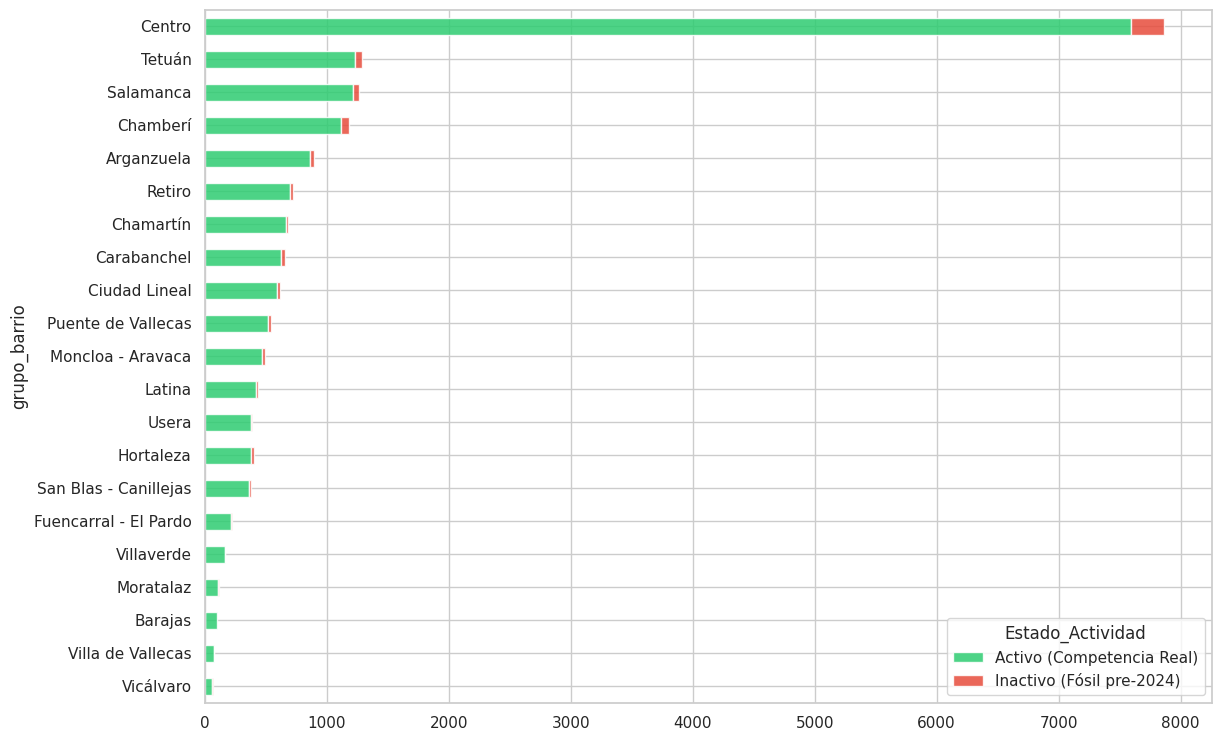

In [19]:
# Definimos tu límite superior matemático calculado
limite_outlier_superior = 305.0

# OPCIÓN A: Creamos dos DataFrames separados para el inversor
df_madrid_estandar = df[df['precio'] <= limite_outlier_superior].copy()
df_madrid_luxury = df[df['precio'] > limite_outlier_superior].copy()

print(f"Mercado Estándar disponible para análisis ordinario: {df_madrid_estandar.shape[0]} alojamientos")
print(f"Mercado de Lujo/Premium aislado para análisis especial: {df_madrid_luxury.shape[0]} alojamientos")

# Creamos una copia de trabajo del DataFrame principal para las siguientes operaciones
df_working = df.copy()

# Convert 'ultima_resena' to datetime, handling NaNs
df_working['ultima_resena'] = pd.to_datetime(df_working['ultima_resena'], errors='coerce')

# 1. Creamos la columna de estado basada en tu criterio de seguridad cronológica
# (Asegúrate de usar tus nombres de columnas traducidos)
df_working['Estado_Actividad'] = 'Inactivo (Fósil pre-2024)'

# Condición de vigencia: Reseña reciente o anuncio nuevo con precio
# Using translated column names: 'ultima_resena', 'cantidad_resenas'
filtro_vivo = (df_working['ultima_resena'].dt.year >= 2024) | (df_working['cantidad_resenas'] == 0)
df_working.loc[filtro_vivo, 'Estado_Actividad'] = 'Activo (Competencia Real)'

# 2. Filtramos también por tu rango de precio operativo (<= 500) para que todo sea consistente
# Using translated column name: 'precio'
df_grafico_cruzado = df_working[df_working['precio'] <= 500.0]

# 3. Agrupamos y contamos las propiedades por Distrito y Estado de Actividad
# Using translated column name: 'grupo_barrio'
conteo_cruzado = df_grafico_cruzado.groupby(['grupo_barrio', 'Estado_Actividad']).size().unstack(fill_value=0)

# 4. Ordenamos el reporte por la cantidad de competidores ACTIVOS para mantener la jerarquía comercial
conteo_cruzado = conteo_cruzado.sort_values(by='Activo (Competencia Real)', ascending=True)

# 5. Configuramos el lienzo de visualización ejecutiva
plt.figure(figsize=(13, 9))
sns.set_theme(style="whitegrid")

# 6. Dibujamos el gráfico de barras horizontales apiladas (Stacked Bar Chart)
# Usamos colores estratégicos: un tono elegante para los vivos y uno suave/alerta para los fósiles
conteo_cruzado.plot(
    kind='barh',
    stacked=True,
    ax=plt.gca(),
    color=['#2ecc71', '#e74c3c'], # Verde para Activos, Rojo para Inactivos
    alpha=0.85,
    edgecolor='white'
)

plt.show()

Cada barra representa un distrito, y el largo total muestra la cantidad de propiedades. El color verde indica las propiedades Activas y el rojo las Inactivas, permitiéndote ver de un vistazo qué tan 'viva' o 'fósil' es la competencia en cada zona.

○ ¿Cuáles son los distritos (neighbourhood_group) con más publicaciones? (Identificar dónde está la saturación comercial).

In [ ]:
# 1. Calculamos la cantidad exacta de anuncios (competencia) por cada Distrito
anuncios_por_distrito = df_madrid_estandar['grupo_barrio'].value_counts()

# 2. Calculamos el porcentaje de participación (cuota de mercado) de cada zona
porcentaje_distrito = df_madrid_estandar['grupo_barrio'].value_counts(normalize=True) * 100

# 3. Consolidamos los datos en un DataFrame de reporte gerencial
reporte_saturacion = pd.DataFrame({
    'Total_Alojamientos': anuncios_por_distrito,
    'Cuota_Mercado_Share': porcentaje_distrito
})

# 4. Formateamos la columna de porcentaje para que sea perfectamente legible (ej: 25.40%)
reporte_saturacion['Cuota_Mercado_Share'] = reporte_saturacion['Cuota_Mercado_Share'].map('{:.2f}%'.format)

# 5. Mostramos el reporte completo ordenado automáticamente de mayor a menor saturación
print("--- REPORTE EJECUTIVO: SATURACIÓN COMERCIAL EN MADRID ---")
display(reporte_saturacion)
print("-" * 70)

# Extraemos el distrito rey de la saturación para la narrativa automática
distrito_top = reporte_saturacion.index[0]
cantidad_top = reporte_saturacion.iloc[0]['Total_Alojamientos']
porcentaje_top = reporte_saturacion.iloc[0]['Cuota_Mercado_Share']

print(f"🚨 CONCLUSIÓN DETECTADA: El distrito con mayor saturación comercial es '{distrito_top}'")
print(f"con un total de {cantidad_top} competidores activos, acaparando el {porcentaje_top} del mercado total.")

--- REPORTE EJECUTIVO: SATURACIÓN COMERCIAL EN MADRID ---


,Total_Alojamientos,Cuota_Mercado_Share
grupo_barrio,,
Centro,7411,41.71%
Tetuán,1272,7.16%
Salamanca,1164,6.55%
Chamberí,1125,6.33%
Arganzuela,885,4.98%
Retiro,696,3.92%
Chamartín,663,3.73%
Carabanchel,648,3.65%
Ciudad Lineal,596,3.35%


----------------------------------------------------------------------
🚨 CONCLUSIÓN DETECTADA: El distrito con mayor saturación comercial es 'Centro'
con un total de 7411 competidores activos, acaparando el 41.71% del mercado total.


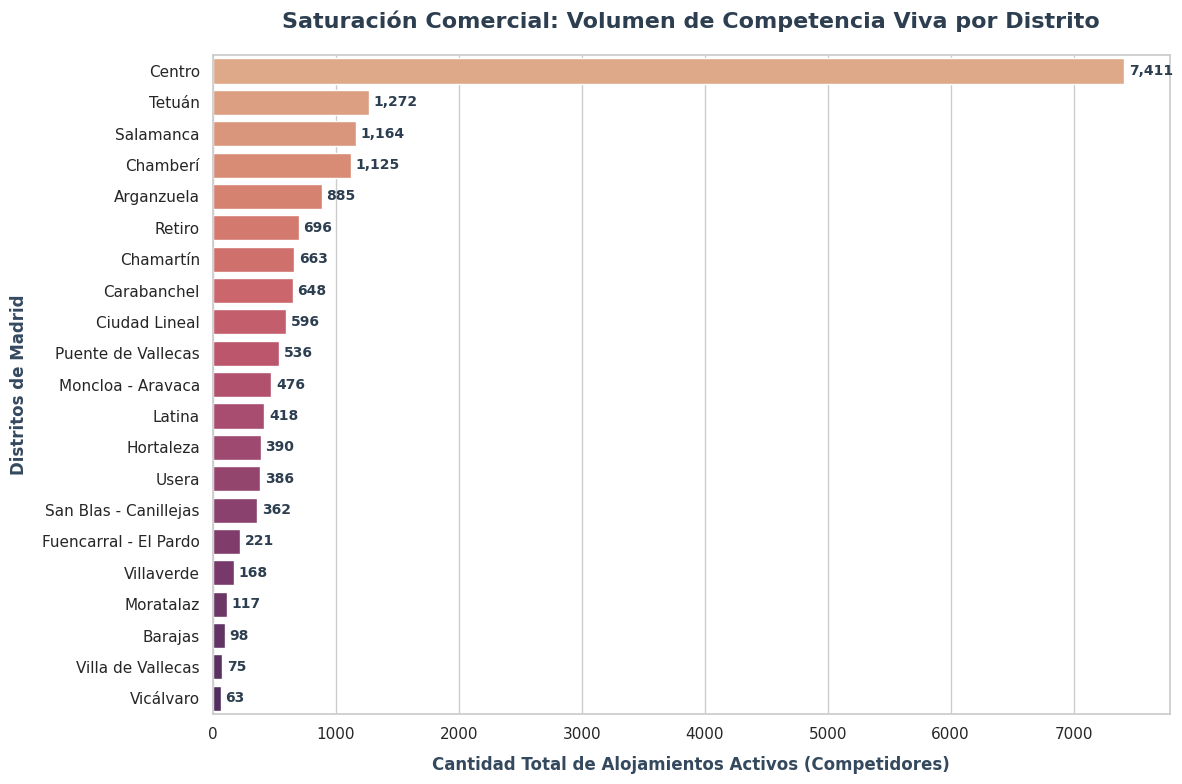

In [ ]:
# 1. Extraemos los datos del conteo y nos aseguramos de que estén ordenados de mayor a menor
datos_grafico = anuncios_por_distrito

# 2. Configuramos el tamaño del lienzo (proporción estilizada para 21 distritos)
plt.figure(figsize=(12, 8))

# 3. Activamos un estilo de fondo limpio y profesional
sns.set_theme(style="whitegrid")

# 4. Creamos el gráfico de barras horizontales aplicando el degradado 'flare'
# Al pasar x e y de esta manera, las barras se dibujan horizontalmente
sns.barplot(
    x=datos_grafico.values,
    y=datos_grafico.index,
    palette='flare',
    hue=datos_grafico.index,  # Evita advertencias de futuras versiones de Seaborn
    legend=False
)

# 5. Personalizamos los títulos y etiquetas con tipografías legibles y formales
plt.title('Saturación Comercial: Volumen de Competencia Viva por Distrito', fontsize=16, fontweight='bold', pad=20, color='#2c3e50')
plt.xlabel('Cantidad Total de Alojamientos Activos (Competidores)', fontsize=12, fontweight='bold', labelpad=10, color='#34495e')
plt.ylabel('Distritos de Madrid', fontsize=12, fontweight='bold', labelpad=10, color='#34495e')

# 6. Agregamos las etiquetas de datos (el número exacto) al final de cada barra para que el inversor no tenga que adivinar
for index, value in enumerate(datos_grafico.values):
    plt.text(
        value + (datos_grafico.max() * 0.005),  # Pequeño margen a la derecha del final de la barra
        index,                                  # Posición vertical centrada en la barra
        f'{value:,}',                           # Formato del número con separador de miles
        va='center',                            # Alineación vertical al centro
        ha='left',                              # Alineación horizontal a la izquierda
        fontsize=10,
        fontweight='bold',
        color='#2c3e50'
    )

# 7. Ajustamos los márgenes para que no se corte ningún texto al exportar
plt.tight_layout()

# 8. Guardamos el gráfico en alta definición por si necesitás pegarlo en un informe de Word o PDF
plt.savefig('saturacion_comercial_madrid.png', dpi=300, bbox_inches='tight')

# 9. Mostramos la obra de arte en la pantalla del Colab
plt.show()

● 2.2. Variables Numéricas (El comportamiento):

○ ¿Cuál es el mínimo de noches (minimum_nights) más común? ¿Existen valores raros (como exigencias de más de 365 noches)?

In [ ]:
# 1. ANÁLISIS ANALÍTICO - NOCHES MÍNIMAS

moda_noches = df['minimo_noches'].mode()[0]
raros_noches = (df['minimo_noches'] > 365).sum()

print("--- DIAGNÓSTICO ESTADÍSTICO OPERATIVO ---")
print(f"1. El mínimo de noches más común (Moda) en Madrid es: {moda_noches} noche(s).")
print(f"2. Propiedades con exigencias absurdas (Mayores a 365 noches): {raros_noches} anuncios.")

--- DIAGNÓSTICO ESTADÍSTICO OPERATIVO ---
1. El mínimo de noches más común (Moda) en Madrid es: 1 noche(s).
2. Propiedades con exigencias absurdas (Mayores a 365 noches): 14 anuncios.


○ ¿Cómo se distribuye la disponibilidad (availability_365)? ¿Hay muchas propiedades con disponibilidad 0?

<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_3955/3098847959.py:8: SyntaxWarning: invalid escape sequence '\l'
  ax.set_title('Distribución de Noches Mínimas (Mercado Estándar $\leq$ 30)', fontsize=12, fontweight='bold', pad=15)


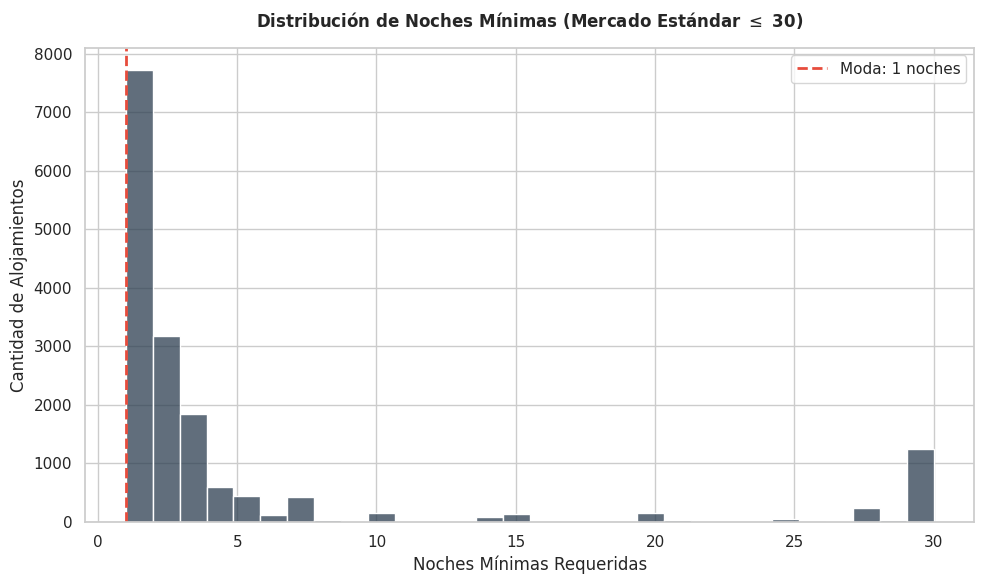

In [ ]:
# --- GRÁFICO 1: HISTOGRAMA DE NOCHES MÍNIMAS (Filtrado a <= 30 para ver el comportamiento común) ---
# Usamos un filtro temporal visual de <= 30 noches para que el gráfico no se deforme por los outliers
fig, ax = plt.subplots(figsize=(10, 6)) # Inicializamos la figura y un único eje
noches_filtradas = df_madrid_estandar[df_madrid_estandar['minimo_noches'] <= 30]['minimo_noches']

sns.histplot(noches_filtradas, bins=30, kde=False, color='#2c3e50', ax=ax, edgecolor='white')
ax.axvline(moda_noches, color='#e74c3c', linestyle='--', linewidth=2, label=f'Moda: {moda_noches} noches')
ax.set_title('Distribución de Noches Mínimas (Mercado Estándar $\leq$ 30)', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Noches Mínimas Requeridas')
ax.set_ylabel('Cantidad de Alojamientos')
ax.legend()
# Ajustes de empaque visual estético
plt.tight_layout()
plt.savefig('comportamiento_variables_numericas.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# 2. ANÁLISIS ANALÍTICO - DISPONIBILIDAD 0
# ==========================================================
total_dispo_cero = (df['disponibilidad_anual'] == 0).sum()
porcentaje_dispo_cero = (total_dispo_cero / df.shape[0]) * 100

print(f"3. Propiedades con Disponibilidad igual a 0: {total_dispo_cero} ({porcentaje_dispo_cero:.2f}% del dataset).")

3. Propiedades con Disponibilidad igual a 0: 5039 (20.16% del dataset).


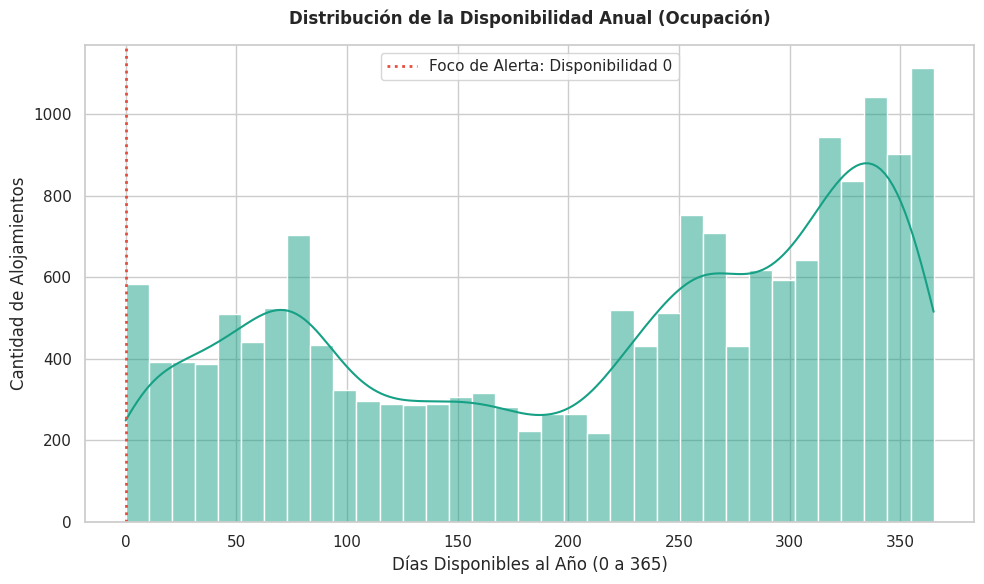

In [ ]:
# --- GRÁFICO 2: HISTOGRAMA DE DISPONIBILIDAD ANUAL ---
fig, ax = plt.subplots(figsize=(10, 6)) # Inicializamos la figura y un único eje
sns.histplot(df_madrid_estandar['disponibilidad_anual'], bins=35, kde=True, color='#16a085', ax=ax, edgecolor='white')
ax.axvline(0, color='#e74c3c', linestyle=':', linewidth=2, label='Foco de Alerta: Disponibilidad 0')
ax.set_title('Distribución de la Disponibilidad Anual (Ocupación)', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Días Disponibles al Año (0 a 365)')
ax.set_ylabel('Cantidad de Alojamientos')
ax.legend()

# Ajustes de empaque visual estético
plt.tight_layout()
plt.savefig('comportamiento_variables_numericas.png', dpi=300, bbox_inches='tight')
plt.show()

## Fase 3: Análisis de Hallazgos Accionables para el Inversor (Precio < 305 Euros)

Esta sección se enfocará en propiedades con un precio por noche *inferior a 305 Euros*, buscando insights accionables para un inversor en este segmento de mercado más accesible, que representa la mayoría de las propiedades después de excluir los outliers superiores.

### 3.1. Precio según la Ubicación (Distrito)

Analizaremos cómo el precio varía en función del distrito. Identificaremos los distritos más caros y más baratos en promedio y mediana, lo cual es crucial para la estrategia de inversión.

DataFrame filtrado para Precio_Noche < 305: 17757 filas y 18 columnas.

--- Precios Promedio y Mediano por Distrito (Precio < 305 Euros) ---


,mean,median
Distrito,,
Salamanca,139.895099,134.0
Centro,131.158336,122.0
Chamberí,121.627556,115.0
Chamartín,118.348416,117.0
Retiro,116.959712,112.0
Arganzuela,103.923164,95.0
Tetuán,103.643868,98.0
Moncloa - Aravaca,101.752101,90.0
Barajas,95.683673,88.5


/tmp/ipykernel_426/3304970732.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Precio_Noche', y='Distrito', data=df_filtro_precio.sort_values('Precio_Noche', ascending=False), palette='viridis')


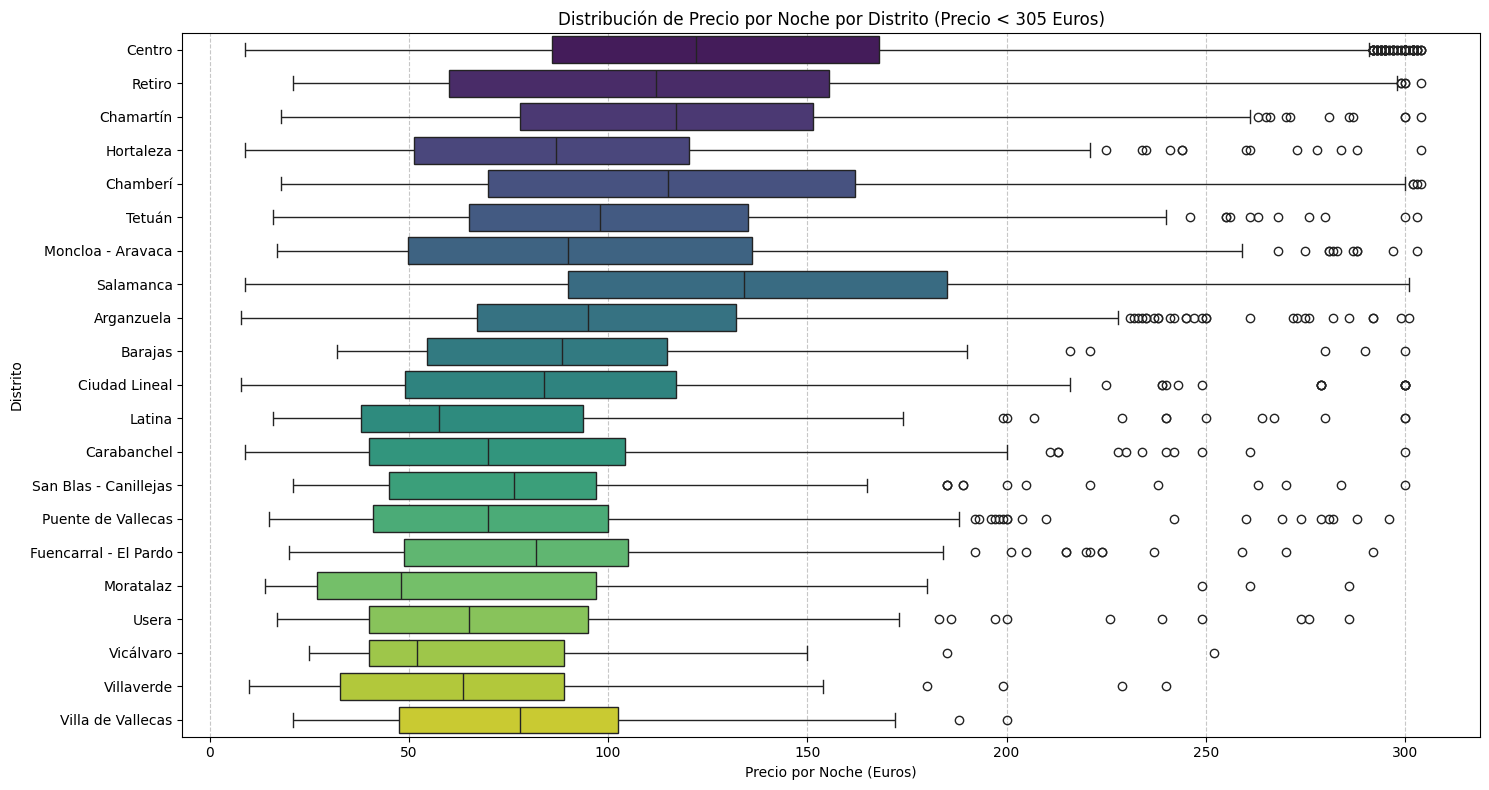

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Filtrar el DataFrame para incluir solo propiedades con precio < 305
# Se crea un nuevo DataFrame filtrado para esta fase para asegurar que los cálculos y gráficos solo usen estos datos.
df_filtro_precio = df[df['precio'] < 305].copy()

print(f"DataFrame filtrado para precio < 305: {df_filtro_precio.shape[0]} filas y {df_filtro_precio.shape[1]} columnas.\n")

# Calcular el precio promedio y mediano por Distrito
precio_por_distrito = df_filtro_precio.groupby('Distrito')['precio'].agg(['mean', 'median']).sort_values(by='mean', ascending=False)

print("--- Precios Promedio y Mediano por Distrito (precio < 305 Euros) ---")
display(precio_por_distrito)

# Boxplot comparativo de precio por Distrito
plt.figure(figsize=(15, 8))
sns.boxplot(x='precio', y='Distrito', data=df_filtro_precio.sort_values('precio', ascending=False), palette='viridis')
plt.title('Distribución de precio por Distrito (precio < 305 Euros)')
plt.xlabel('Precio (Euros)')
plt.ylabel('Distrito')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


DataFrame filtrado para Precio_Noche < 305: 17757 filas y 18 columnas.

--- Precios Promedio y Mediano por Barrio (Precio < 305 Euros) ---


,mean,median
Barrio,,
Castellana,162.347826,162.5
Costillares,153.717949,132.0
Recoletos,153.341346,150.5
Lista,147.216867,140.5
Sol,146.584677,141.0
...,...,...
Portazgo,51.000000,44.0
Campamento,48.538462,40.0
San Cristobal,46.357143,45.5


/tmp/ipykernel_426/2554251746.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Precio_Noche', y='Barrio', data=df_filtro_precio.sort_values('Precio_Noche', ascending=False), palette='viridis')


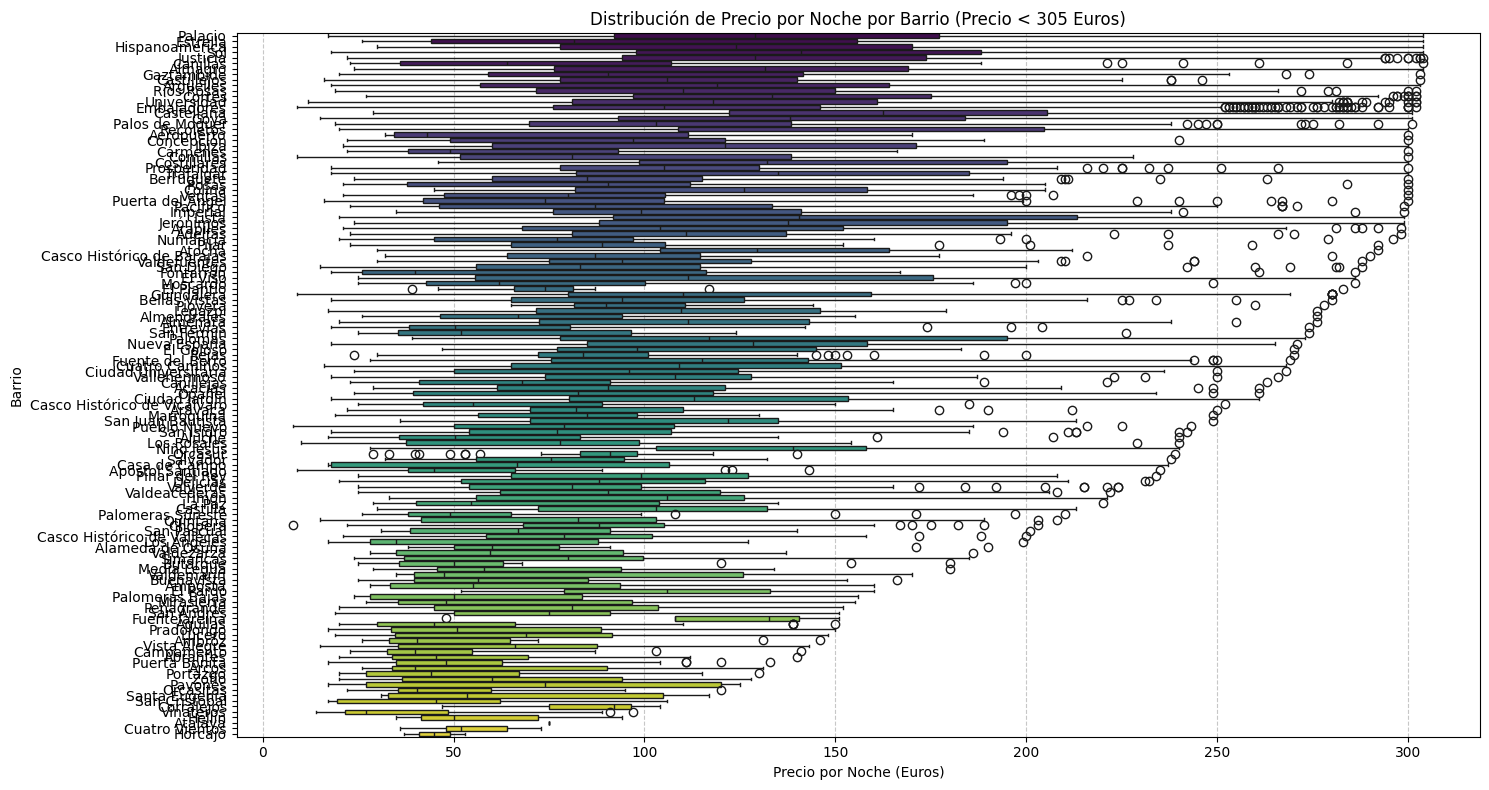

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Filtrar el DataFrame para incluir solo propiedades con precio < 305
# Se crea un nuevo DataFrame filtrado para esta fase para asegurar que los cálculos y gráficos solo usen estos datos.
df_filtro_precio = df[df['precio'] < 305].copy()

print(f"DataFrame filtrado para precio < 305: {df_filtro_precio.shape[0]} filas y {df_filtro_precio.shape[1]} columnas.\n")

# Calcular el precio promedio y mediano por Barrio
precio_por_barrio = df_filtro_precio.groupby('Barrio')['precio'].agg(['mean', 'median']).sort_values(by='mean', ascending=False)

print("--- Precios Promedio y Mediano por Barrio (precio < 305 Euros) ---")
display(precio_por_barrio)

# Boxplot comparativo de precio por Barrio
plt.figure(figsize=(15, 8))
sns.boxplot(x='precio', y='Barrio', data=df_filtro_precio.sort_values('precio', ascending=False), palette='viridis')
plt.title('Distribución de precio por Barrio (precio < 305 Euros)')
plt.xlabel('Precio (Euros)')
plt.ylabel('Barrio')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### 3.2. Precio según el Tipo de Propiedad

Esta sección explora cómo el tipo de alojamiento (e.g., 'Entire home/apt' vs. 'Private room') influye en el precio. Esta información es vital para un inversor que decide qué tipo de propiedad adquirir.

In [20]:
# Calcular el precio promedio por tipo_habitacion
precio_por_tipo = df_filtro_precio.groupby('tipo_habitacion')['precio'].mean().sort_values(ascending=False)

print("--- Precio Promedio por Tipo de Habitación (precio < 305 Euros) ---")
display(precio_por_tipo)

# Gráfico de barras con intervalos de confianza mostrando el precio promedio por tipo_habitacion
plt.figure(figsize=(10, 6))
sns.barplot(x='tipo_habitacion', y='precio', data=df_filtro_precio, palette='magma', errorbar='sd') # 'sd' para desviación estándar como barra de error
plt.title('Precio Promedio por Tipo de Habitación (precio < 305 Euros)')
plt.xlabel('Tipo de Habitación')
plt.ylabel('Precio Promedio (Euros)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


NameError: name 'df_filtro_precio' is not defined

### 3.3. Geolocalización del Valor

Visualizaremos la distribución espacial de los precios en Madrid utilizando la latitud y longitud. Esto permitirá identificar zonas de "alto valor" (hotspots) que podrían no ser evidentes solo con el análisis por distrito.

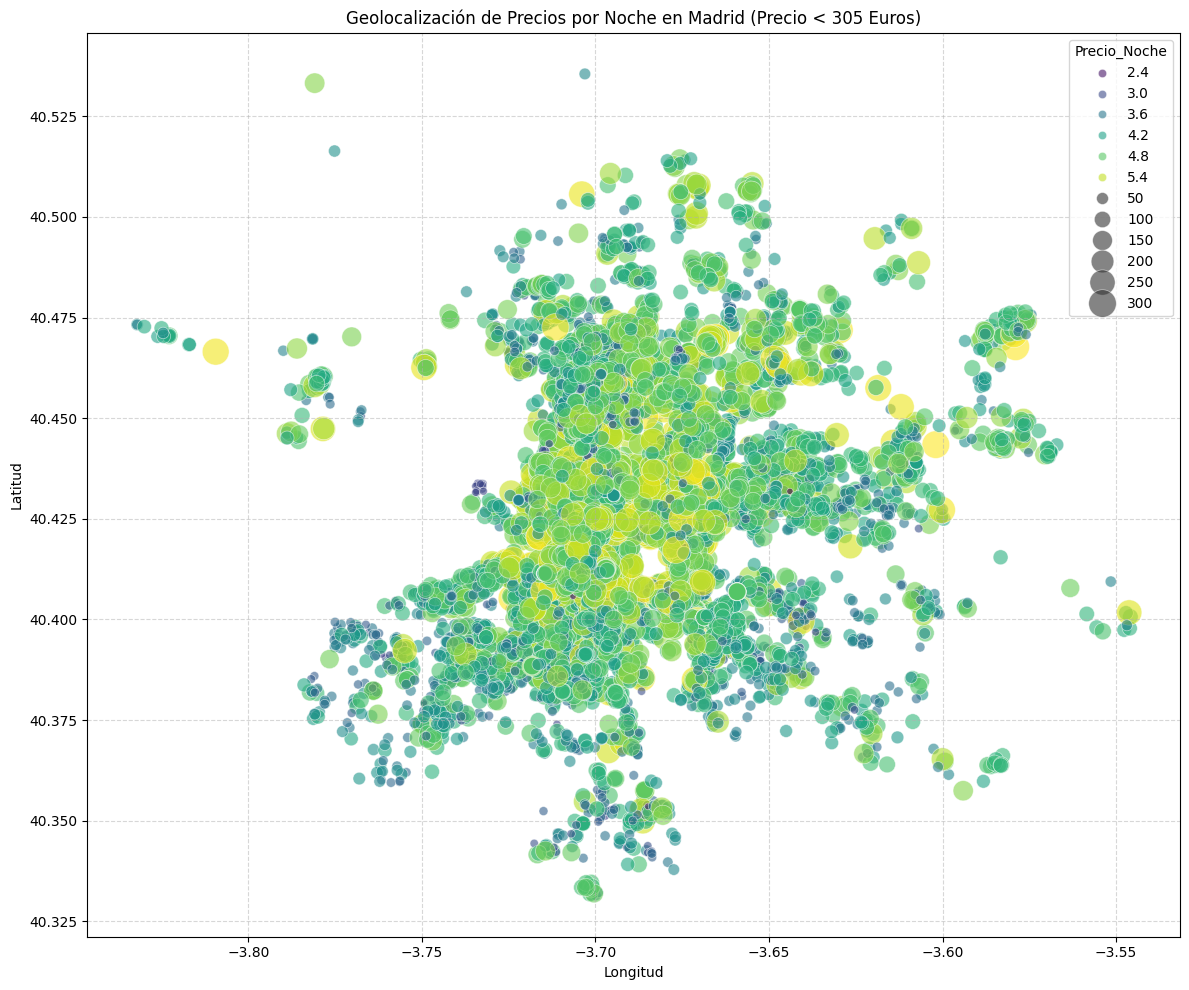

In [ ]:
# Gráfico de dispersión (Scatter plot) geolocalizado con color por precio (escala logarítmica)
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='longitud',
    y='latitud',
    hue=np.log1p(df_filtro_precio['precio']),  # Aplicar log1p para manejar la asimetría y el color
    size='precio',  # El tamaño del punto puede indicar el precio
    sizes=(20, 400),  # Rango de tamaños de los puntos
    data=df_filtro_precio,
    palette='viridis',
    alpha=0.6,
    edgecolor='w',
    linewidth=0.5
)
plt.title('Geolocalización de precios en Madrid (precio < 305 Euros)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(True, linestyle='--', alpha=0.5)

# Crear una barra de color manual para la leyenda de 'hue'
# La leyenda de hue se escala en log, pero se muestra con valores originales
# sns.scatterplot automáticamente maneja la leyenda de color si hue es numérico y se usa 'palette'

plt.tight_layout()
plt.show()


# Fase 4: Análisis de Relaciones y Potencial de Negocio

Para entender cómo interactúan las variables entre sí y qué palancas mueven la demanda, realizaremos un análisis de correlación y la relación entre ocupación y precio.

## 4.1. Correlación de Variables: Mapa de Calor (Heatmap)

¿Las propiedades con más reseñas mensuales (`Reseñas_Por_Mes`) tienden a bajar los precios para atraer gente, o los anfitriones profesionales (`Total_Propiedades_Anfitrion`) logran cobrar más caro?

Este gráfico nos permitirá visualizar la fuerza y dirección de la relación lineal entre todas las variables numéricas.

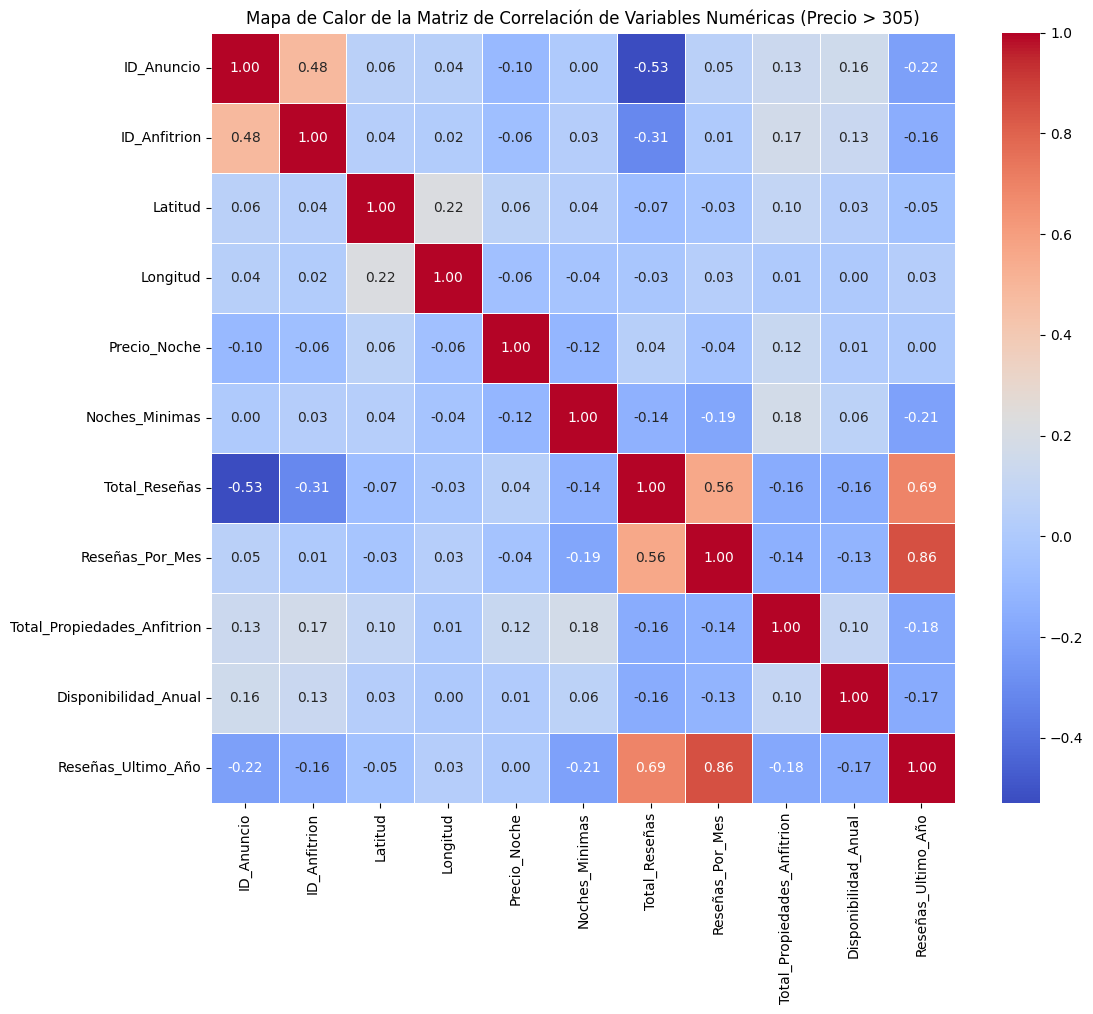

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar el DataFrame para incluir solo propiedades con precio > 305
df_filtered_high_price = df[df['precio'] > 305].copy()

# Seleccionar solo las columnas numéricas para el cálculo de la correlación del DataFrame filtrado
columnas_numericas = df_filtered_high_price.select_dtypes(include=['float64', 'int64']).columns

# Calcular la matriz de correlación de Pearson para el DataFrame filtrado
matriz_correlacion = df_filtered_high_price[columnas_numericas].corr(method='pearson')

# Configurar el tamaño de la figura para el mapa de calor
plt.figure(figsize=(12, 10))

# Crear el mapa de calor
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)

plt.title('Mapa de Calor de la Matriz de Correlación de Variables Numéricas (precio > 305)')
plt.show()


El mapa de calor muestra las correlaciones entre pares de variables numéricas. Un valor cercano a 1 indica una fuerte correlación positiva, un valor cercano a -1 indica una fuerte correlación negativa, y un valor cercano a 0 indica poca o ninguna correlación lineal. Esto nos ayuda a identificar relaciones que podrían ser interesantes para un análisis más profundo.

## 4.2. Relación Ocupación vs. Precio: Gráfico de Dispersión (Regplot)

Analizar si los precios altos reducen drásticamente la disponibilidad disponible o si el volumen de reseñas se mantiene constante. Nos enfocaremos en la relación entre `Precio_Noche` y `Reseñas_Por_Mes` como proxy de ocupación y atractivo del anuncio.

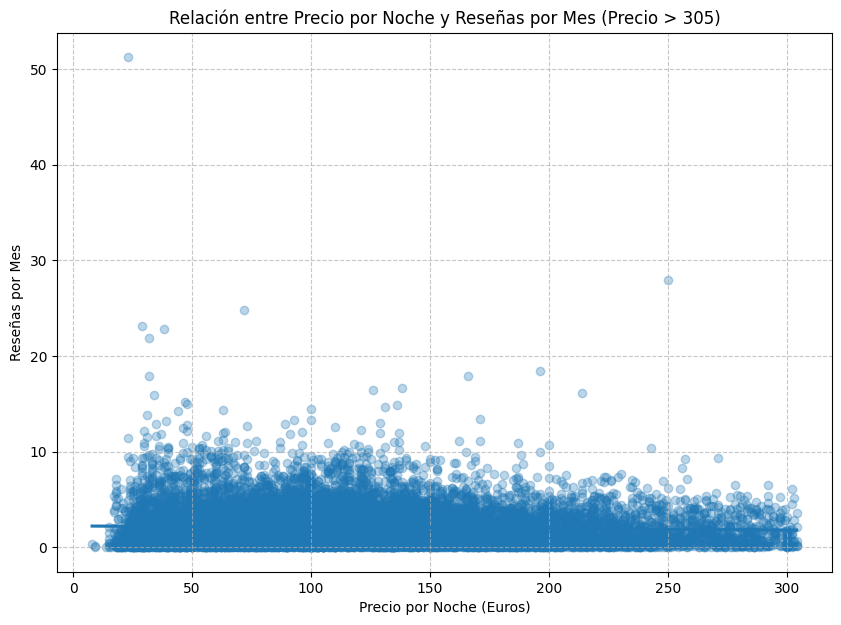

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar el DataFrame para incluir solo propiedades con Precio_Noche > 305 y eliminar nulos
df_filtered = df[(df['Precio_Noche'] < 305)].dropna(subset=['Precio_Noche', 'Reseñas_Por_Mes'])

# Crear el gráfico de dispersión con línea de tendencia (Regplot)
plt.figure(figsize=(10, 7))
sns.regplot(x='Precio_Noche', y='Reseñas_Por_Mes', data=df_filtered, scatter_kws={'alpha':0.3})

plt.title('Relación entre Precio por Noche y Reseñas por Mes (Precio > 305)')
plt.xlabel('Precio por Noche (Euros)')
plt.ylabel('Reseñas por Mes')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Este gráfico de dispersión con una línea de regresión nos ayuda a visualizar la tendencia. Si la línea de regresión tiene una pendiente negativa, podría indicar que un precio más alto se asocia con menos reseñas mensuales (posiblemente menor ocupación). Si es positiva o plana, podría sugerir lo contrario o ninguna relación lineal clara. La dispersión de los puntos también nos dará una idea de la variabilidad en esta relación.

In [ ]:
# Filtrar el DataFrame para mostrar filas donde 'disponibilidad_anual' es igual a 0
filas_precio_alto = df[df['disponibilidad_anual'] == 0]

# Mostrar las primeras 20 filas completas de este subconjunto
display(filas_precio_alto.head(20))


,ID_Anuncio,Nombre_Anuncio,ID_Anfitrion,Nombre_Anfitrion,Distrito,Barrio,Latitud,Longitud,Tipo_Alojamiento,Precio_Noche,Noches_Minimas,Total_Reseñas,Fecha_Ultima_Reseña,Reseñas_Por_Mes,Total_Propiedades_Anfitrion,Disponibilidad_Anual,Reseñas_Ultimo_Año,license
2,30959,Beautiful loft in Madrid Center,132883,Angela,Centro,Embajadores,40.41259,-3.70105,Entire home/apt,NaN,3,8,2017-05-30,0.06,1,0,0,NaN
5,70059,Tu hogar en centro de Madrid.,353616,Diana,Centro,Universidad,40.42381,-3.71038,Entire home/apt,NaN,7,64,2025-06-23,0.36,1,0,3,VT-7440
9,82481,"Retiro Park, Stay at cosy studio",448981,Mercedes,Salamanca,Recoletos,40.42342,-3.68123,Entire home/apt,NaN,3,105,2017-11-29,0.60,1,0,0,NaN
12,100411,Ático muy luminoso,527760,Diana,Fuencarral - El Pardo,Valverde,40.50044,-3.67032,Entire home/apt,NaN,2,3,2016-06-24,0.03,1,0,0,NaN
13,102040,Nice Single Room with wifi.,533936,Carlos Alberto,Ciudad Lineal,Pueblo Nuevo,40.43422,-3.64196,Private room,NaN,3,0,NaN,NaN,1,0,0,NaN
15,136058,"Calm, affordable room in Madrid.",666482,Cinthia,Villaverde,Los Angeles,40.35761,-3.69723,Private room,24.0,1,97,2022-10-30,0.56,1,0,0,NaN
20,200828,"FRENTE MAR, ZONA CALAS. PISCINA.",75944,Maite,Salamanca,Castellana,40.43201,-3.68358,Entire home/apt,NaN,14,0,NaN,NaN,1,0,0,33866
25,225489,Madrid City Center. Room for 1 or 2 people.,1172225,Eva,Chamberí,Arapiles,40.43595,-3.70706,Private room,NaN,25,30,2020-03-07,0.19,3,0,0,NaN
34,287660,Beatiful downtown room with balcony,1496188,Juanpe,Centro,Universidad,40.42683,-3.71108,Private room,NaN,1,11,2014-11-08,0.07,2,0,0,NaN
37,336672,Great apartment ∞4 rooms∞ close to City Center,1716726,Jesús,Arganzuela,Delicias,40.39516,-3.69309,Entire home/apt,NaN,2,198,2025-01-10,2.09,1,0,15,NaN


## **🧹2. Transformación y Preparación de Datos**

## **🤖3. Modelo Predictivo de Machine Learning**

## **🧪4. Evaluación del Modelo y Conclusiones**